# Joint Detection of AI-Generated Images and Post-Processing Alterations

This notebook implements the current baseline phase of the Computer Vision project:

**Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios**

Each input image has two labels:

1. A binary source label: `ai` or `real`.
2. A post-processing label: `original`, `redigital`, or `transfer`.

The final project will use one shared Transformer visual backbone with two classification heads. This notebook implements only the two independent baselines needed before the multi-task model:

1. Binary baseline: `ai` vs `real`.
2. Transformation baseline: `original` vs `redigital` vs `transfer`.

Both baselines use the same selected Transformer backbone, controlled by `SELECTED_BACKBONE`.

## 1. Imports

The project uses PyTorch and Hugging Face Transformers. Generic visual Transformer backbones such as DeiT and Swin are loaded through `AutoModel` and `AutoImageProcessor`. CLIP is handled separately because it is an image-text model; only its visual encoder is used here.

In [1]:
import copy
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoConfig,
    AutoImageProcessor,
    AutoModel,
    CLIPImageProcessor,
    CLIPModel,
)

/opt/homebrew/Caskroom/miniconda/base/envs/ML2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Globals

Only one backbone is selected for this baseline notebook. Change `SELECTED_BACKBONE` to switch between the supported Transformer backbones. The notebook trains only the selected backbone, not all available models.

In [2]:
# Dataset structure
DATA_ROOT = Path("./data/raw/RRDataset_final")
CLASS_NAMES = ["ai", "real"]
TRANSFORM_NAMES = ["original", "redigital", "transfer"]
SUBFOLDERS = TRANSFORM_NAMES

CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
TRANSFORM_TO_IDX = {name: idx for idx, name in enumerate(TRANSFORM_NAMES)}

IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}
IDX_TO_TRANSFORM = {idx: name for name, idx in TRANSFORM_TO_IDX.items()}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Reproducibility
SEED = 42

# Balanced subset size. If None, use the smallest available joint group size.
SAMPLES_PER_GROUP = 300

# Select exactly one Transformer backbone for both baselines.
SELECTED_BACKBONE = "swin-tiny"

MODEL_CONFIGS = {
    "deit-tiny": {
        "type": "generic",
        "name": "facebook/deit-tiny-patch16-224",
    },
    "deit-small": {
        "type": "generic",
        "name": "facebook/deit-small-patch16-224",
    },
    "swin-tiny": {
        "type": "generic",
        "name": "microsoft/swin-tiny-patch4-window7-224",
    },
    "clip-vit-b": {
        "type": "clip",
        "name": "openai/clip-vit-base-patch32",
    },
}

FREEZE_BACKBONE = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

BATCH_SIZE = 16
NUM_WORKERS = min(4, max(1, (os.cpu_count() or 2) // 2))

TEST_SIZE = 0.2
VAL_SIZE = 0.1
USE_GROUP_SPLIT = True

NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 4
MIN_DELTA = 1e-4

CHECKPOINT_DIR = Path("./checkpoints/baselines")
RESULTS_DIR = Path("./results/baselines")

if SELECTED_BACKBONE not in MODEL_CONFIGS:
    raise ValueError(f"Unknown SELECTED_BACKBONE={SELECTED_BACKBONE!r}. Choose one of {list(MODEL_CONFIGS)}")

print(f"Device: {DEVICE}")
print(f"Selected backbone: {SELECTED_BACKBONE}")

Device: mps
Selected backbone: swin-tiny


## 3. Utils

These helper functions make the notebook reproducible, create output folders, load the appropriate Hugging Face image processor, and release GPU/MPS cache between experiments.

In [3]:
def set_seed(seed: int = SEED) -> None:
    """Make sampling, splitting, and model initialization reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def ensure_output_dirs() -> None:
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def is_image_file(path: Path) -> bool:
    return path.suffix.lower() in IMAGE_EXTENSIONS


def get_selected_model_config() -> dict:
    return MODEL_CONFIGS[SELECTED_BACKBONE]


def get_image_processor(cfg: dict):
    if cfg["type"] == "clip":
        return CLIPImageProcessor.from_pretrained(cfg["name"])
    return AutoImageProcessor.from_pretrained(cfg["name"])


def clear_memory() -> None:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if DEVICE.type == "mps":
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

## 4. Data

The expected dataset layout is:

```text
data/raw/RRDataset_final/
    original/
        ai/
        real/
    redigital/
        ai/
        real/
    transfer/
        ai/
        real/
```

Each image is indexed with both labels. The binary label answers whether the image is AI-generated or real. The transformation label describes the post-processing condition. The balanced subset is sampled over the six joint groups `label x subfolder`, not only over `ai` and `real`, because both classification tasks must see all source/transformation combinations.

In [4]:
def build_image_index(data_root: Path = DATA_ROOT) -> pd.DataFrame:
    """
    Walk the dataset folder structure and build one dataframe row per image.

    Columns:
        path, label, subfolder, binary_label, transform_label, stratify_key, image_id
    """
    records = []

    for subfolder in SUBFOLDERS:
        for class_name in CLASS_NAMES:
            class_dir = data_root / subfolder / class_name
            if not class_dir.is_dir():
                print(f"[warning] missing folder: {class_dir}")
                continue

            for img_path in class_dir.rglob("*"):
                if img_path.is_file() and is_image_file(img_path):
                    records.append(
                        {
                            "path": str(img_path),
                            "label": class_name,
                            "subfolder": subfolder,
                            "binary_label": CLASS_TO_IDX[class_name],
                            "transform_label": TRANSFORM_TO_IDX[subfolder],
                            "stratify_key": f"{class_name}_{subfolder}",
                            "image_id": img_path.stem,
                        }
                    )

    df = pd.DataFrame(records)
    if df.empty:
        raise RuntimeError(f"No images found under {data_root}. Check the dataset path/structure.")

    return df.reset_index(drop=True)


def print_dataset_audit(df: pd.DataFrame, title: str) -> None:
    print(f"\n== {title} ==")
    print(f"Total images: {len(df)}")
    print("\nBy binary label:")
    print(df["label"].value_counts().sort_index())
    print("\nBy transformation:")
    print(df["subfolder"].value_counts().sort_index())
    print("\nBy label x transformation:")
    print(df.groupby(["label", "subfolder"]).size())


def sample_balanced_joint_subset(
    df: pd.DataFrame,
    samples_per_group: int | None = SAMPLES_PER_GROUP,
    seed: int = SEED,
) -> pd.DataFrame:
    """Sample an equal number of images from each label x transformation group."""
    group_counts = df.groupby(["label", "subfolder"]).size()
    expected_groups = len(CLASS_NAMES) * len(TRANSFORM_NAMES)
    if len(group_counts) != expected_groups:
        raise RuntimeError(
            "The dataset does not contain all label x transformation groups. "
            f"Found {len(group_counts)} groups, expected {expected_groups}."
        )

    min_available = int(group_counts.min())
    if samples_per_group is None:
        n_take = min_available
    else:
        n_take = min(samples_per_group, min_available)
        if samples_per_group > min_available:
            print(
                f"[warning] requested {samples_per_group} samples per joint group, "
                f"but the smallest group has only {min_available}. Using {n_take}."
            )

    subsets = []
    for class_name in CLASS_NAMES:
        for subfolder in SUBFOLDERS:
            group_df = df[(df["label"] == class_name) & (df["subfolder"] == subfolder)]
            subsets.append(group_df.sample(n=n_take, random_state=seed))

    subset_df = pd.concat(subsets, ignore_index=True)
    return subset_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)


def split_dataframe(df: pd.DataFrame, seed: int = SEED):
    """
    Create one fixed train/validation/test split for both baselines.

    If image_id repeats across rows, GroupShuffleSplit is used to reduce leakage between
    transformed versions of the same image. Otherwise, the split is stratified by the
    joint label x transformation key.
    """
    repeated_ids = df["image_id"].duplicated().any()

    if USE_GROUP_SPLIT and repeated_ids:
        print("\nUsing group split by image_id to reduce leakage between transformed versions.")

        splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
        train_val_idx, test_idx = next(splitter.split(df, groups=df["image_id"]))
        train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
        test_df = df.iloc[test_idx].reset_index(drop=True)

        splitter_val = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=seed)
        train_idx, val_idx = next(splitter_val.split(train_val_df, groups=train_val_df["image_id"]))
        train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
        val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

        print("[note] GroupShuffleSplit does not guarantee perfect class stratification.")
        print("[note] Check the split distributions printed below.")
    else:
        print("\nUsing stratified split by label x transformation.")

        train_val_df, test_df = train_test_split(
            df,
            test_size=TEST_SIZE,
            stratify=df["stratify_key"],
            random_state=seed,
        )
        train_df, val_df = train_test_split(
            train_val_df,
            test_size=VAL_SIZE,
            stratify=train_val_df["stratify_key"],
            random_state=seed,
        )

        train_df = train_df.reset_index(drop=True)
        val_df = val_df.reset_index(drop=True)
        test_df = test_df.reset_index(drop=True)

    return train_df, val_df, test_df


class AIRealTransformDataset(Dataset):
    """
    Dataset returning:
        pixel_values, binary_label, transform_label
    """

    def __init__(self, dataframe: pd.DataFrame, image_processor):
        self.df = dataframe.reset_index(drop=True)
        self.image_processor = image_processor

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        pixel_values = self.image_processor(images=image, return_tensors="pt")["pixel_values"][0]

        binary_label = int(row["binary_label"])
        transform_label = int(row["transform_label"])

        return pixel_values, binary_label, transform_label


def make_loaders(train_df, val_df, test_df, image_processor):
    train_dataset = AIRealTransformDataset(train_df, image_processor)
    val_dataset = AIRealTransformDataset(val_df, image_processor)
    test_dataset = AIRealTransformDataset(test_df, image_processor)

    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": DEVICE.type == "cuda",
        "persistent_workers": NUM_WORKERS > 0,
    }
    if NUM_WORKERS > 0 and os.name != "nt":
        # In notebooks on macOS/Linux, fork avoids pickling issues with Dataset classes defined in cells.
        loader_kwargs["multiprocessing_context"] = "fork"

    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

    sample_pixels, sample_binary, sample_transform = train_dataset[0]
    print(
        f"Sample tensor shape: {sample_pixels.shape}, "
        f"binary={sample_binary} ({IDX_TO_CLASS[sample_binary]}), "
        f"transform={sample_transform} ({IDX_TO_TRANSFORM[sample_transform]})"
    )

    return train_loader, val_loader, test_loader

## 5. Network

The two baselines share the same selected Transformer backbone type but are trained as independent single-task models. The binary baseline has two output classes. The transformation baseline has three output classes.

For generic backbones, features are extracted from `pooler_output` when available, otherwise from the CLS token, otherwise by mean pooling over `last_hidden_state`. For CLIP, the visual encoder output is passed through CLIP's visual projection.

In [5]:
class SingleTaskTransformerClassifier(nn.Module):
    """
    Single-head Transformer classifier used for both baselines.

    Args:
        cfg: model configuration from MODEL_CONFIGS.
        num_classes: output classes for the selected task.
        task_name: human-readable task name, either "binary" or "transform".
        freeze_backbone: if True, only the classification head is trained.
    """

    def __init__(
        self,
        cfg: dict,
        num_classes: int,
        task_name: str,
        freeze_backbone: bool = FREEZE_BACKBONE,
    ):
        super().__init__()
        self.cfg = cfg
        self.backbone_type = cfg["type"]
        self.task_name = task_name
        hf_name = cfg["name"]

        config = AutoConfig.from_pretrained(hf_name)
        print(f"Model: {hf_name} | HF model_type: {config.model_type} | task: {task_name}")

        if self.backbone_type == "clip":
            clip_model = CLIPModel.from_pretrained(hf_name)
            self.backbone = clip_model.vision_model
            self.projection = clip_model.visual_projection
            embed_dim = clip_model.config.projection_dim
        else:
            self.backbone = AutoModel.from_pretrained(hf_name)
            self.projection = None
            embed_dim = self._infer_embed_dim(self.backbone)

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            if self.projection is not None:
                for param in self.projection.parameters():
                    param.requires_grad = False

        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    @staticmethod
    def _infer_embed_dim(backbone) -> int:
        cfg = backbone.config
        if hasattr(cfg, "hidden_size"):
            return cfg.hidden_size
        if hasattr(cfg, "embed_dim"):
            return cfg.embed_dim
        if hasattr(cfg, "projection_dim"):
            return cfg.projection_dim
        raise ValueError("Could not infer backbone embedding dimension from config.")

    @staticmethod
    def _pool_generic_output(outputs):
        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            return outputs.pooler_output
        if hasattr(outputs, "last_hidden_state") and outputs.last_hidden_state is not None:
            last_hidden_state = outputs.last_hidden_state
            if last_hidden_state.ndim == 3 and last_hidden_state.shape[1] > 1:
                return last_hidden_state[:, 0]
            return last_hidden_state.mean(dim=1)
        raise ValueError("Backbone output has neither pooler_output nor last_hidden_state.")

    def forward_features(self, pixel_values):
        if self.backbone_type == "clip":
            pooled = self.backbone(pixel_values=pixel_values).pooler_output
            return self.projection(pooled)

        outputs = self.backbone(pixel_values=pixel_values)
        return self._pool_generic_output(outputs)

    def forward(self, pixel_values):
        features = self.forward_features(pixel_values)
        return self.head(features)


def build_model(task: str) -> SingleTaskTransformerClassifier:
    if task == "binary":
        num_classes = len(CLASS_NAMES)
    elif task == "transform":
        num_classes = len(TRANSFORM_NAMES)
    else:
        raise ValueError(f"Unknown task: {task}")

    return SingleTaskTransformerClassifier(
        cfg=get_selected_model_config(),
        num_classes=num_classes,
        task_name=task,
        freeze_backbone=FREEZE_BACKBONE,
    ).to(DEVICE)


def print_model_size(model: nn.Module) -> None:
    total_params = sum(param.numel() for param in model.parameters())
    trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
    print(f"Total parameters:     {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,} (backbone frozen: {FREEZE_BACKBONE})")

## 6. Train

The training loop is shared by both baselines. The only task-specific operation is the label selection: the binary model is trained with `binary_label`, while the transformation model is trained with `transform_label`.

Early stopping monitors validation accuracy and saves the best checkpoint for each baseline.

In [6]:
def select_labels(binary_labels, transform_labels, task: str):
    if task == "binary":
        return binary_labels
    if task == "transform":
        return transform_labels
    raise ValueError(f"Unknown task: {task}")


def run_epoch(model, loader, criterion, task: str, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_training):
        for pixel_values, binary_labels, transform_labels in tqdm(loader, leave=False):
            pixel_values = pixel_values.to(DEVICE)
            labels = select_labels(binary_labels, transform_labels, task).to(DEVICE)

            logits = model(pixel_values)
            loss = criterion(logits, labels)

            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    clear_memory()
    return total_loss / total, correct / total


def train_single_task_model(task: str, train_loader, val_loader):
    model = build_model(task)
    print_model_size(model)

    model.eval()
    with torch.no_grad():
        pixel_values, binary_labels, transform_labels = next(iter(train_loader))
        pixel_values = pixel_values.to(DEVICE)
        logits = model(pixel_values)
        print(f"Logits shape check: {logits.shape}")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda param: param.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    checkpoint_path = CHECKPOINT_DIR / f"{SELECTED_BACKBONE}_{task}.pt"
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    best_val_acc = -np.inf
    best_state_dict = None
    epochs_without_improvement = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, task, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, task, optimizer=None)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc + MIN_DELTA:
            best_val_acc = val_acc
            best_state_dict = copy.deepcopy(model.state_dict())
            torch.save(best_state_dict, checkpoint_path)
            epochs_without_improvement = 0
            print(f"  -> new best val_acc={best_val_acc:.4f}, checkpoint saved to {checkpoint_path}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f"  -> early stopping after {epoch} epochs")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, best_val_acc, checkpoint_path

## 7. Evaluation

The binary baseline is evaluated with accuracy, macro F1, ROC-AUC, a classification report, a confusion matrix, and binary accuracy split by transformation type. The transformation baseline is evaluated with accuracy, macro F1, a classification report, and a confusion matrix.

In [7]:
def predict(model, loader, task: str) -> dict:
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    all_binary_labels = []
    all_transform_labels = []

    with torch.no_grad():
        for pixel_values, binary_labels, transform_labels in tqdm(loader, leave=False):
            pixel_values = pixel_values.to(DEVICE)
            labels = select_labels(binary_labels, transform_labels, task)

            logits = model(pixel_values)
            probs = torch.softmax(logits, dim=1).cpu().numpy()

            all_labels.extend(labels.numpy())
            all_preds.extend(probs.argmax(axis=1))
            all_probs.extend(probs)
            all_binary_labels.extend(binary_labels.numpy())
            all_transform_labels.extend(transform_labels.numpy())

    return {
        "y_true": np.array(all_labels),
        "y_pred": np.array(all_preds),
        "y_prob": np.array(all_probs),
        "binary_true": np.array(all_binary_labels),
        "transform_true": np.array(all_transform_labels),
    }


def compute_metrics(prediction: dict, task: str) -> dict:
    y_true = prediction["y_true"]
    y_pred = prediction["y_pred"]
    y_prob = prediction["y_prob"]

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

    if task == "binary":
        try:
            real_idx = CLASS_TO_IDX["real"]
            metrics["roc_auc"] = roc_auc_score(y_true, y_prob[:, real_idx])
        except Exception:
            metrics["roc_auc"] = np.nan

        for transform_idx, transform_name in IDX_TO_TRANSFORM.items():
            mask = prediction["transform_true"] == transform_idx
            metrics[f"acc_on_{transform_name}"] = (
                accuracy_score(y_true[mask], y_pred[mask]) if mask.sum() > 0 else np.nan
            )
    else:
        metrics["roc_auc"] = np.nan
        for transform_name in TRANSFORM_NAMES:
            metrics[f"acc_on_{transform_name}"] = np.nan

    return metrics


def save_classification_report(prediction: dict, task: str, model_name: str) -> Path:
    target_names = CLASS_NAMES if task == "binary" else TRANSFORM_NAMES
    report = classification_report(
        prediction["y_true"],
        prediction["y_pred"],
        target_names=target_names,
    )
    report_path = RESULTS_DIR / f"report_{model_name}_{task}.txt"
    report_path.write_text(report, encoding="utf-8")
    print("\nClassification report:")
    print(report)
    return report_path


def plot_and_save_confusion_matrix(prediction: dict, task: str, model_name: str) -> Path:
    labels = CLASS_NAMES if task == "binary" else TRANSFORM_NAMES
    cm = confusion_matrix(prediction["y_true"], prediction["y_pred"])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d", xticks_rotation=30)
    plt.title(f"{model_name} - {task} confusion matrix")
    plt.tight_layout()

    out_path = RESULTS_DIR / f"cm_{model_name}_{task}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    plt.close()
    return out_path


def evaluate_single_task_model(
    model,
    test_loader,
    task: str,
    best_val_acc: float,
    checkpoint_path: Path,
) -> dict:
    model_name = f"{SELECTED_BACKBONE}_{task}"
    prediction = predict(model, test_loader, task)
    metrics = compute_metrics(prediction, task)

    print(f"\nTask: {task}")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    print(f"Test accuracy: {metrics['accuracy']:.4f}")
    print(f"Test macro F1: {metrics['macro_f1']:.4f}")

    if task == "binary":
        print(f"Test ROC-AUC: {metrics['roc_auc']:.4f}")
        for transform_name in TRANSFORM_NAMES:
            print(f"Binary accuracy on {transform_name}: {metrics[f'acc_on_{transform_name}']:.4f}")

    report_path = save_classification_report(prediction, task, SELECTED_BACKBONE)
    confusion_matrix_path = plot_and_save_confusion_matrix(prediction, task, SELECTED_BACKBONE)

    return {
        "model_name": model_name,
        "selected_backbone": SELECTED_BACKBONE,
        "task": task,
        "best_val_acc": best_val_acc,
        "test_accuracy": metrics["accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "test_roc_auc": metrics["roc_auc"],
        "binary_acc_original": metrics["acc_on_original"],
        "binary_acc_redigital": metrics["acc_on_redigital"],
        "binary_acc_transfer": metrics["acc_on_transfer"],
        "checkpoint_path": str(checkpoint_path),
        "report_path": str(report_path),
        "confusion_matrix_path": str(confusion_matrix_path),
    }


def save_baseline_results(results: list[dict]) -> pd.DataFrame:
    results_df = pd.DataFrame(results)
    results_path = RESULTS_DIR / "baseline_results.csv"
    results_df.to_csv(results_path, index=False)
    print(f"Saved baseline summary to: {results_path}")
    return results_df

## 8. Final Execution Cells

Run the following cells from top to bottom. They create the output folders, build and audit the dataset, save one shared split, create dataloaders, then train and evaluate the two baselines separately.

### 8.1 Prepare Data and Dataloaders

The same train/validation/test split is reused for both baselines. This makes the comparison fair because the binary and transformation models are evaluated on exactly the same images.

In [8]:
set_seed(SEED)
ensure_output_dirs()

full_index = build_image_index(DATA_ROOT)
print_dataset_audit(full_index, "FULL DATASET")

data_subset = sample_balanced_joint_subset(full_index, SAMPLES_PER_GROUP, SEED)
print_dataset_audit(data_subset, "BALANCED SUBSET")

train_df, val_df, test_df = split_dataframe(data_subset, SEED)

print_dataset_audit(train_df, "TRAIN SPLIT")
print_dataset_audit(val_df, "VALIDATION SPLIT")
print_dataset_audit(test_df, "TEST SPLIT")

train_df.to_csv(RESULTS_DIR / "split_train.csv", index=False)
val_df.to_csv(RESULTS_DIR / "split_val.csv", index=False)
test_df.to_csv(RESULTS_DIR / "split_test.csv", index=False)

image_processor = get_image_processor(get_selected_model_config())
train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df, image_processor)

baseline_results = []


== FULL DATASET ==
Total images: 50999

By binary label:
label
ai      25500
real    25499
Name: count, dtype: int64

By transformation:
subfolder
original     17000
redigital    16999
transfer     17000
Name: count, dtype: int64

By label x transformation:
label  subfolder
ai     original     8500
       redigital    8500
       transfer     8500
real   original     8500
       redigital    8499
       transfer     8500
dtype: int64

== BALANCED SUBSET ==
Total images: 1800

By binary label:
label
ai      900
real    900
Name: count, dtype: int64

By transformation:
subfolder
original     600
redigital    600
transfer     600
Name: count, dtype: int64

By label x transformation:
label  subfolder
ai     original     300
       redigital    300
       transfer     300
real   original     300
       redigital    300
       transfer     300
dtype: int64

Using stratified split by label x transformation.

== TRAIN SPLIT ==
Total images: 1296

By binary label:
label
ai      648
real    648

Sample tensor shape: torch.Size([3, 224, 224]), binary=0 (ai), transform=2 (transfer)


### 8.2 Train and Evaluate Binary Baseline

This baseline answers the first forensic question: is the image AI-generated or real?

Architecture: selected Transformer backbone + binary classification head.

Model: microsoft/swin-tiny-patch4-window7-224 | HF model_type: swin | task: binary


Loading weights: 100%|██████████| 219/219 [00:00<00:00, 8759.72it/s]
[transformers] SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:     27,716,732
Trainable parameters: 197,378 (backbone frozen: True)
Logits shape check: torch.Size([16, 2])


Epoch 01/15 | train_loss=0.5989 train_acc=0.6960 | val_loss=0.4890 val_acc=0.8333
  -> new best val_acc=0.8333, checkpoint saved to checkpoints/baselines/swin-tiny_binary.pt


Epoch 02/15 | train_loss=0.4516 train_acc=0.8279 | val_loss=0.3881 val_acc=0.8750
  -> new best val_acc=0.8750, checkpoint saved to checkpoints/baselines/swin-tiny_binary.pt


...

Epoch 05/15 | train_loss=0.2669 train_acc=0.9120 | val_loss=0.2795 val_acc=0.9028


Epoch 06/15 | train_loss=0.2372 train_acc=0.9275 | val_loss=0.2655 val_acc=0.8958


Epoch 07/15 | train_loss=0.2062 train_acc=0.9383 | val_loss=0.2608 val_acc=0.8958


Epoch 08/15 | train_loss=0.1855 train_acc=0.9475 | val_loss=0.2514 val_acc=0.8958
  -> early stopping after 8 epochs



Task: binary
Best validation accuracy: 0.9028
Test accuracy: 0.8583
Test macro F1: 0.8582
Test ROC-AUC: 0.9412
Binary accuracy on original: 0.8500
Binary accuracy on redigital: 0.8583
Binary accuracy on transfer: 0.8667

Classification report:
              precision    recall  f1-score   support

          ai       0.84      0.89      0.86       180
        real       0.88      0.83      0.85       180

    accuracy                           0.86       360
   macro avg       0.86      0.86      0.86       360
weighted avg       0.86      0.86      0.86       360



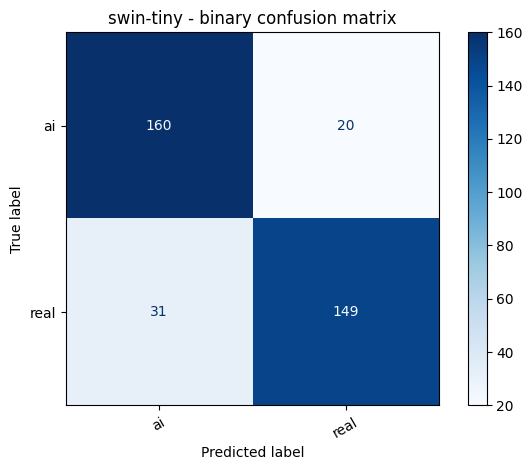

{'model_name': 'swin-tiny_binary',
 'selected_backbone': 'swin-tiny',
 'task': 'binary',
 'best_val_acc': 0.9027777777777778,
 'test_accuracy': 0.8583333333333333,
 'test_macro_f1': 0.8582009437823894,
 'test_roc_auc': 0.9412345679012346,
 'binary_acc_original': 0.85,
 'binary_acc_redigital': 0.8583333333333333,
 'binary_acc_transfer': 0.8666666666666667,
 'checkpoint_path': 'checkpoints/baselines/swin-tiny_binary.pt',
 'report_path': 'results/baselines/report_swin-tiny_binary.txt',
 'confusion_matrix_path': 'results/baselines/cm_swin-tiny_binary.png'}

In [9]:
binary_model, binary_history, binary_best_val_acc, binary_checkpoint_path = train_single_task_model(
    task="binary",
    train_loader=train_loader,
    val_loader=val_loader,
)

binary_result = evaluate_single_task_model(
    model=binary_model,
    test_loader=test_loader,
    task="binary",
    best_val_acc=binary_best_val_acc,
    checkpoint_path=binary_checkpoint_path,
)
baseline_results.append(binary_result)

binary_result

### 8.3 Train and Evaluate Transformation Baseline

This baseline answers the second forensic question: which post-processing transformation has been applied?

Architecture: the same selected Transformer backbone type + transformation classification head.

Model: microsoft/swin-tiny-patch4-window7-224 | HF model_type: swin | task: transform


Loading weights: 100%|██████████| 219/219 [00:00<00:00, 7742.68it/s]
[transformers] SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:     27,716,989
Trainable parameters: 197,635 (backbone frozen: True)
Logits shape check: torch.Size([16, 3])


Epoch 01/15 | train_loss=1.0586 train_acc=0.4699 | val_loss=1.0196 val_acc=0.5833
  -> new best val_acc=0.5833, checkpoint saved to checkpoints/baselines/swin-tiny_transform.pt


Epoch 02/15 | train_loss=0.9239 train_acc=0.6782 | val_loss=0.9382 val_acc=0.6319
  -> new best val_acc=0.6319, checkpoint saved to checkpoints/baselines/swin-tiny_transform.pt


...

Epoch 06/15 | train_loss=0.5834 train_acc=0.8194 | val_loss=0.7621 val_acc=0.7014


Epoch 07/15 | train_loss=0.5286 train_acc=0.8403 | val_loss=0.7407 val_acc=0.7014


Epoch 08/15 | train_loss=0.4799 train_acc=0.8542 | val_loss=0.7351 val_acc=0.6944


Epoch 09/15 | train_loss=0.4412 train_acc=0.8781 | val_loss=0.7135 val_acc=0.7083
  -> early stopping after 9 epochs



Task: transform
Best validation accuracy: 0.7153
Test accuracy: 0.6806
Test macro F1: 0.6825

Classification report:
              precision    recall  f1-score   support

    original       0.59      0.65      0.62       120
   redigital       0.78      0.68      0.72       120
    transfer       0.70      0.72      0.71       120

    accuracy                           0.68       360
   macro avg       0.69      0.68      0.68       360
weighted avg       0.69      0.68      0.68       360



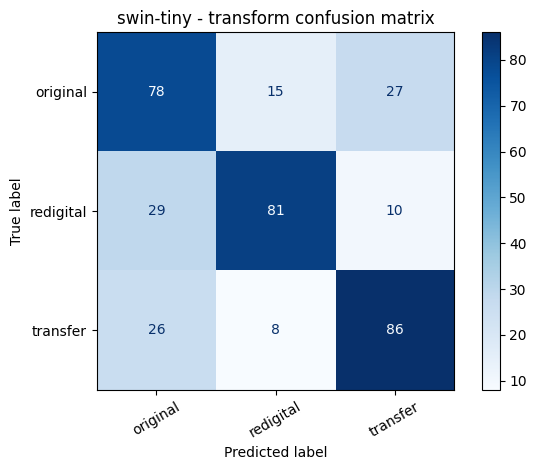

{'model_name': 'swin-tiny_transform',
 'selected_backbone': 'swin-tiny',
 'task': 'transform',
 'best_val_acc': 0.7152777777777778,
 'test_accuracy': 0.6805555555555556,
 'test_macro_f1': 0.682544668756424,
 'test_roc_auc': nan,
 'binary_acc_original': nan,
 'binary_acc_redigital': nan,
 'binary_acc_transfer': nan,
 'checkpoint_path': 'checkpoints/baselines/swin-tiny_transform.pt',
 'report_path': 'results/baselines/report_swin-tiny_transform.txt',
 'confusion_matrix_path': 'results/baselines/cm_swin-tiny_transform.png'}

In [10]:
transform_model, transform_history, transform_best_val_acc, transform_checkpoint_path = train_single_task_model(
    task="transform",
    train_loader=train_loader,
    val_loader=val_loader,
)

transform_result = evaluate_single_task_model(
    model=transform_model,
    test_loader=test_loader,
    task="transform",
    best_val_acc=transform_best_val_acc,
    checkpoint_path=transform_checkpoint_path,
)
baseline_results.append(transform_result)

transform_result

### 8.4 Save Baseline Summary

The summary CSV contains one row for the binary baseline and one row for the transformation baseline.

In [11]:
baseline_results_df = save_baseline_results(baseline_results)
baseline_results_df

Saved baseline summary to: results/baselines/baseline_results.csv


,model_name,selected_backbone,task,best_val_acc,test_accuracy,test_macro_f1,test_roc_auc,binary_acc_original,binary_acc_redigital,binary_acc_transfer,checkpoint_path,report_path,confusion_matrix_path
0,swin-tiny_binary,swin-tiny,binary,0.902778,0.858333,0.858201,0.941235,0.85,0.858333,0.866667,checkpoints/baselines/swin-tiny_binary.pt,results/baselines/report_swin-tiny_binary.txt,results/baselines/cm_swin-tiny_binary.png
1,swin-tiny_transform,swin-tiny,transform,0.715278,0.680556,0.682545,NaN,NaN,NaN,NaN,checkpoints/baselines/swin-tiny_transform.pt,results/baselines/report_swin-tiny_transform.txt,results/baselines/cm_swin-tiny_transform.png


## Multi-Task Model Placeholder

The final model will reuse the same selected Transformer backbone and add two heads:

1. A binary head for `ai` vs `real`.
2. A transformation head for `original` vs `redigital` vs `transfer`.

The future training objective will combine the two cross-entropy losses:

```text
total_loss = lambda_binary * CE_binary + lambda_transform * CE_transform
```

This multi-task model is intentionally not implemented in this baseline notebook. It will be added after the independent baselines are stable.

## Next Steps

1. Select the final Transformer backbone.
2. Add the multi-task model with shared backbone and two heads.
3. Add weighted loss ablation.
4. Compare baselines against the multi-task model.
5. Analyze binary detection performance across transformation types.